# Week 9 – The Space of Borel Probability Distributions

## Why Study Measure Theory in AI?

> In what follows, we will work extensively with **probability distributions**. We will need to compare distributions by defining suitable notions of **distance**, and analyze the **convergence of sequences of distributions**. These questions naturally arise, for example, when studying the behavior of stochastic optimization algorithms used to train modern machine learning models.


### Important application field: Generative AI


<div style="display: flex;">
  <div style="flex: 50%; padding: 10px;">
    <p>
        
**Goal of generative models** e.g. GANs, VAEs, and diffusion-based models
  - Learn an **unknown data distribution** $\mathbb{P}_{\text{data}}$
  - Generate new samples that are **indistinguishable** from real data
  - Formally: construct a model distribution $\mathbb{P}_\theta \approx \mathbb{P}_{\text{data}}$
  
**Core mathematical problem**
  - Compare probability measures:
    - How close is $\mathbb{P}_\theta$ to $\mathbb{P}_{\text{data}}$?
  - Optimize over distributions:
    - Minimize a divergence or distance:
    - KR distance, Wasserstein distance, total variation, KL divergence etc.
        
  </p>
  </div>
  <div style="flex: 50%; padding: 10px;">
    <p><div style="text-align: center;">
<img src="./AImeasure.png" width="450" height="300">
</div></p>
  </div>
</div>

>## Takeaway
>- Modern AI = **learning and transforming probability measures**
>- Measure theory provides the **language, tools, and guarantees** for this process


## From Physical Quantities to Probability Measures


<div style="display: flex;">
  <div style="flex: 50%; padding: 10px;">
    <p>
        
- **Extensive quantities** in physiscs measure how much of something is contained in a given region. 

- Examples include volume, mass, electric charge, or energy. 

- A fundamental property is **additivity**:
    * if a system is decomposed into disjoint parts, the total quantity is the sum over those parts.

>**Probability behaves in exactly the same way**
>- Instead of spatial regions, we now consider **events** (subsets of all possible outcomes).
>- The probability of an event $A$, denoted by $\mathbb{P}(A)$, can be interpreted as the “amount of likelihood” assigned to $A$.
>- Thus probability is an additive quantity on events.

  </p>
  </div>
  <div style="flex: 50%; padding: 10px;">
  <p>

<div style="text-align: center;">
<img src="./extensive.png" width="450" height="300">
</div>

  </div>
</div>

This idea leads to the abstract concept of a **measure**: a function $\mu$ that assigns a nonnegative number to each set $A$, representing the “amount” of something in $A$, and satisfying additivity:
$$
\mu\!\left(\bigcup_i A_i\right) = \sum_i \mu(A_i)
\quad \text{for disjoint sets } A_i.
$$

We require $\sigma$-additivity, which is a stronger condition than finite additivity.

#### Density representation

Extensive quantities can be often expressed via a densities. For example, mass can be written as
$$
\text{mass}(A) = \int_A \rho(x)\,dx,
$$
where $\rho(x)$ is the mass density. Here, the density describes how the quantity is distributed locally, while the integral gives the total amount.

Just as in physics, probabilities may admit a **density description**. For a continuous random variable,
$$
\mathbb{P} (A) = \int_A f(x)\,dx,
$$
where $f(x)$ is the **probability density function (pdf)**.

Here:
- the **measure** $\mathbb{P}$ gives total probability,
- the **density** $f$ describes how probability is distributed locally.

However, just like point masses in physics, not all probability distributions have a density (e.g., discrete distributions). This highlights the advantage of the abstract notion of a measure.

>**Summary**
>- Extensive quantities in physics → additive set functions  
>- Measure → abstract “total amount”  
>- Probability → measure on events  
>- Density → local description (when it exists)  

## Borel $\sigma$-algebra and Probability Measures

**Definition:** Let $(X,d)$ be a metric space. The **Borel $\sigma$-algebra** on $X$, denoted by $\mathcal{B}(X)$, is the smallest collection of subsets $\mathcal{B}(X) \subset 2^X$ such that:

1. $B_r(x) \in \mathcal{B}(X)$ for all $x \in X$ and $r \ge 0$, i.e., it contains all open balls,

2. if $A \in \mathcal{B}(X)$, then $X \setminus A \in \mathcal{B}(X)$,

3. if $A_n \in \mathcal{B}(X)$ for all $n \in \mathbb{N}$, then $\bigcup_{n \in \mathbb{N}} A_n \in \mathcal{B}(X)$.

---

We will use **Borel $\sigma$-algebras** to model events. 
- The intended meaning of condition (2) is that if $A$ is an event, then the non-occurrence of $A$ should also be an event.
- Condition (3) expresses that if $A_1, A_2, \ldots$ is a (at most) **countable collection** of events, then the event that *at least one of them occurs* should also belong to the system.

**Remark:** In measure-theoretic terminology, the prefix $\sigma$ typically indicates closure under **countable** operations.

---

**What sets belong to the Borel $\sigma$-algebra?**  
Consider, for example, the $\sigma$-algebra $\mathcal{B}(\mathbb{R})$. Clearly, it contains:

- all open intervals  
- all closed intervals  
- intervals of the form $(-\infty, a]$  
- singleton sets $\{x\}$  
- all countable unions, intersections, and complements of such sets e.g. $\mathbb{Q}$ 

**and this list is far from exhaustive.**

---

### The Cantor Set: A Nontrivial Borel Set

The **Cantor set** is a classical example of a set that is highly nontrivial and yet belongs to the Borel $\sigma$-algebra.

#### Construction

Start with the interval $[0,1]$. At each step, remove the open middle third of every remaining interval:

- Step 0: $C_0 = [0,1]$
- Step 1: remove $(\tfrac{1}{3}, \tfrac{2}{3})$, obtaining
  $$
  C_1 = [0,\tfrac{1}{3}] \cup [\tfrac{2}{3},1]
  $$
- Step 2: remove the middle thirds of both intervals:
  $$
  C_2 = [0,\tfrac{1}{9}] \cup [\tfrac{2}{9},\tfrac{1}{3}] \cup [\tfrac{2}{3},\tfrac{7}{9}] \cup [\tfrac{8}{9},1]
  $$
- Continue this process indefinitely.

The **Cantor set** is defined as
$$
C = \bigcap_{n=0}^\infty C_n.
$$

---

#### Basic Properties

- $C$ is **closed**, since it is an intersection of closed sets.
- Therefore, $C \in \mathcal{B}(\mathbb{R})$ (every closed set is a Borel set).
- $C$ is **uncountable**, even though it contains no intervals.
- $C$ has **Lebesgue measure zero**.
- Every point in $C$ can be represented in base 3 using only the digits $0$ and $2$.

---

#### Why is this important?

The Cantor set shows that Borel sets can be extremely complicated:

- It is not an interval, nor a finite or countable union of intervals.
- It has a fractal-like, highly fragmented structure.
- It is “large” in terms of cardinality (uncountable), but “small” in terms of measure (zero).

---

#### Conclusion

Even though the Borel $\sigma$-algebra is generated from simple building blocks (open sets), it already contains sets with very rich and counterintuitive structure. The Cantor set is a fundamental example illustrating this phenomenon.

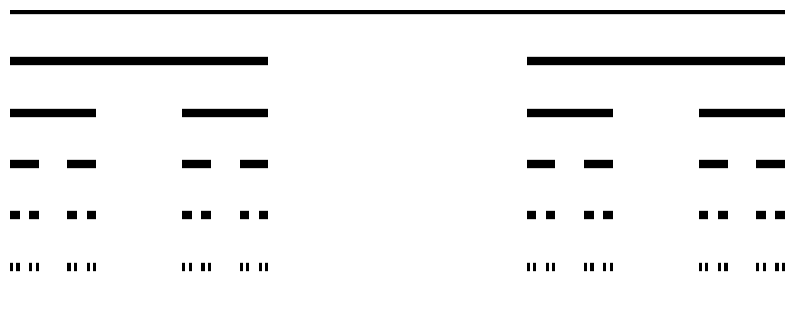

In [1]:
import matplotlib.pyplot as plt

# Paraméterek
levels = 6  # iterációk száma
height = 0.1  # vonalak vastagsága
y_gap = 0.15  # függőleges távolság az iterációk között

# Ábra beállítása
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0, 1)
ax.set_ylim(0, levels * (height + y_gap))
ax.axis('off')  # tengelyek kikapcsolása

# Cantor halmaz rekurzív felépítése
def cantor_intervals(x_start, x_end, level):
    if level == 0:
        return [(x_start, x_end)]
    else:
        third = (x_end - x_start) / 3
        left = cantor_intervals(x_start, x_start + third, level - 1)
        right = cantor_intervals(x_end - third, x_end, level - 1)
        return left + right

# Iterált szintek megjelenítése
for i in range(levels):
    intervals = cantor_intervals(0, 1, i)
    y = levels * (height + y_gap) - i * (height + y_gap)
    for x_start, x_end in intervals:
        ax.hlines(y, x_start, x_end, linewidth=6, color='black')

plt.show()

### The Sierpinski Triangle 

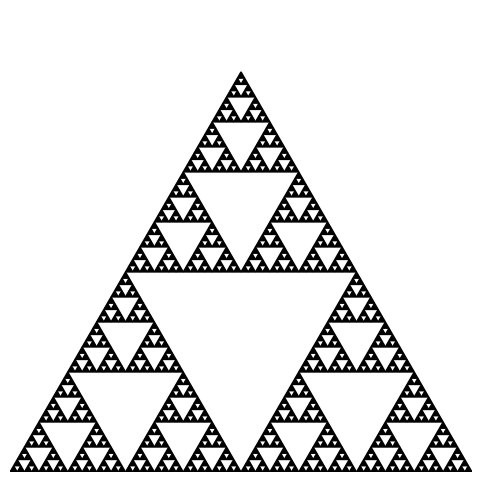

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def sierpinski(vertices, level):
    """
    Recursive function to generate the Sierpinski triangle.
    
    Parameters:
    vertices: 3x2 array containing the triangle's vertices
    level: number of recursion levels
    """
    if level == 0:
        # Base case: draw the triangle
        triangle = plt.Polygon(vertices, color='black')
        plt.gca().add_patch(triangle)
    else:
        # Compute midpoints of the triangle's sides
        mid01 = (vertices[0] + vertices[1]) / 2
        mid12 = (vertices[1] + vertices[2]) / 2
        mid20 = (vertices[2] + vertices[0]) / 2
        
        # Recursively draw the three smaller triangles
        sierpinski(np.array([vertices[0], mid01, mid20]), level-1)
        sierpinski(np.array([mid01, vertices[1], mid12]), level-1)
        sierpinski(np.array([mid20, mid12, vertices[2]]), level-1)

# Define the vertices of the base triangle
vertices = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])

# Set up the figure
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')  # Equal aspect ratio to avoid distortion
ax.axis('off')           # Hide axes

# Generate the Sierpinski triangle
sierpinski(vertices, level=6)  # Number of recursion levels

plt.show()

## Measures

**Definition:** A mapping $\mu : \mathcal{B}(X) \to [0,\infty)$ is called a **measure** if it is countably additive on disjoint sets, that is,
$$
\mu\!\left(\bigcup_{n\in\mathbb{N}} A_n\right) = \sum_{n\in\mathbb{N}} \mu(A_n),
$$
whenever $A_n \in \mathcal{B}(X)$, $n \in \mathbb{N}$, are pairwise disjoint.

- A measure $\mu$ is called a **probability measure** if $\mu(X) = 1$.

- The **support** of a measure consists of those points whose every neighborhood has positive measure:

$$
\mathrm{Sp}(\mu) = \{x \in X \mid \forall r > 0,\; \mu(B_r(x)) > 0\}.
$$

- We say that a statement $p(x)$, $x \in X$, holds **$\mu$-almost everywhere** (or **almost surely** in probability theory) if, for
$$
H = \{x \in X \mid p(x) = \mathrm{false}\},
$$
there exists, for every $n \ge 1$, a set $H_n \in \mathcal{B}(X)$ such that $H \subseteq H_n$ and
$$
\mu(H_n) \le \frac{1}{n}.
$$

---

**Remark:** A probability measure is uniquely determined by its values on open balls.

---

## Examples

**Example 1 (Dirac measure):**  
Let $x_0 \in \mathbb{R}^d$ be fixed. Define
$$
\delta_{x_0}(A) = \mathbb{1}_{\{x_0 \in A\}}.
$$
Then $\delta_{x_0}$ is a measure on $\mathcal{B}(\mathbb{R}^d)$, called the **Dirac measure concentrated at $x_0$**.

---

**Example 2 (Empirical measure):**  
Let $x_1, \ldots, x_n \in \mathbb{R}^d$, and let $w_1, \ldots, w_n \ge 0$ be weights such that $\sum_{k=1}^n w_k = 1$. Then
$$
\mu = \sum_{k=1}^n w_k \,\delta_{x_k}
$$
is a probability measure on $\mathcal{B}(\mathbb{R}^d)$.

- This measure is called the **empirical measure** concentrated on the points $x_1, \ldots, x_n$.
- The weights $w_1, \ldots, w_n$ are often referred to as **importance weights**.
- Every probability measure on $\mathbb{R}^d$ can be approximated (in suitable metrics) by empirical measures.

---

**Example 3 (Lebesgue measure):**  
If $(a,b) \subset \mathbb{R}$ is an interval, define
$$
\lambda((a,b)) = b - a.
$$
This extends to a measure $\lambda$ on $\mathcal{B}(\mathbb{R})$, called the **Lebesgue measure**.


## Measurable Functions and the Integral

Let $f : X \to Y$ be a function.

- The preimage of a set $A \subseteq Y$ under $f$ is defined by
$$
f^{-1}(A) = \{x \in X \mid f(x) \in A\}.
$$

- The function $f$ is called **measurable** if $f^{-1}(A) \in \mathcal{B}(X)$ for every $A \in \mathcal{B}(Y)$.

- If $(X,\mathcal{B}(X),\mathbb{P})$ is a probability space, then $f$ is called a **random variable**.

- The sum, difference, product, and quotient (where defined) of measurable functions are measurable.

- The composition of measurable functions is measurable.

- For a sequence of measurable functions, the pointwise limit, $\sup$, $\inf$, $\limsup$, and $\liminf$ are measurable.


**Proposition.**  
Let $f : X \to Y$ be measurable and let $\mu$ be a measure on $X$. Then
$$
(\mu \circ f^{-1})(A) := \mu\big(\stackrel{-1}{f}(A)\big), \quad A \in \mathcal{B}(Y),
$$
defines a measure on $Y$.

- This measure is called the **pushforward** of $\mu$ under $f$.
- If $f$ is a random variable, it is called the **distribution** (law) of $f$.


**Example.**  
Let $A, A_i \in \mathcal{B}(X)$ and $c_i \in \mathbb{R}$ for $i=1,\dots,n$. The indicator function of $A$ is
$$
\mathbf{1}_A(x) =
\begin{cases}
1, & x \in A, \\
0, & \text{otherwise}.
\end{cases}
$$
Finite linear combinations of indicator functions,
$$
\phi(x) = \sum_i c_i \mathbf{1}_{A_i}(x),
$$
are called **simple functions**, and they are measurable.


#### Integral

1. If $\phi : X \to \mathbb{R}$ is a simple function, define
$$
\int_X \phi(x)\,\mu(dx) := \sum_i c_i\,\mu(A_i).
$$

2. If $\phi : X \to \mathbb{R}$ is nonnegative $\mu$-almost everywhere, define
$$
\int_X \phi(x)\,\mu(dx)
:= \sup \left\{ \int_X s(x)\,\mu(dx) \;\middle|\; s \le \phi,\; s \text{ simple} \right\}.
$$

3. For a general measurable function $\phi : X \to \mathbb{R}$, define
$$
\int_X \phi(x)\,\mu(dx)
:= \int_X \phi_+(x)\,\mu(dx) - \int_X \phi_-(x)\,\mu(dx),
$$
provided the right-hand side is not of the form $\infty - \infty$.

**Theorem (Markov-inequality):** Let $f : X \to [0,\infty]$ be a measurable function. Then for every $t > 0$,
$$
\mu(\{x \in X : f(x) \ge t\}) \le \frac{1}{t} \int_X f \, d\mu.
$$

The probabilist formulation: 
$$
\mathbb{P}(f\ge t)\le\frac{\mathbb{E}[f]}{t},\quad t>0.
$$

**Theorem (Change of variables):**  
Let $f : X \to Y$ be measurable. Then for every measurable function $g : Y \to \mathbb{R}$,
$$
\int_Y g(y)\, d(\mu \circ f^{-1}) = \int_X g(f(x))\, d\mu,
$$
where the existence of one of the integrals implies the existence of the other.


**Example.**  
Let $f : X \to \mathbb{R}$ be a random variable on the probability space $(X,\mathcal{B}(X),\mathbb{P})$. Its expectation is defined by
$$
\mathbb{E}[f] := \int_X f(x)\,\mathbb{P}(dx).
$$

By the change of variables formula, the expectation can also be computed using the distribution of $f$:
$$
\mathbb{E}[f]
= \int_X f(x)\,\mathbb{P}(dx)
= \int_{\mathbb{R}} y \, (\mathbb{P} \circ f^{-1})(dy).
$$

**Example:** Let $\mu = \sum_{k=1}^n w_k \,\delta_{x_k}$
be an empirical measure on $X$, and $f:X\to\mathbb{R}$ be a measurable function. Then $\mu\circ f^{-1} \sum_{k=1}^n w_k\,\delta_{f(x_k)}$, moreover
$$
\int_X f(x)\,\mu (x) = \sum_{k=1}^n w_kf(x_k) = \int_{\mathbb{R}} y\, \mu\circ f^{-1}(dy).
$$

E[f(X)] = 0.4052761210607903
Integral w.r.t. pushforward = 0.40523318031455746


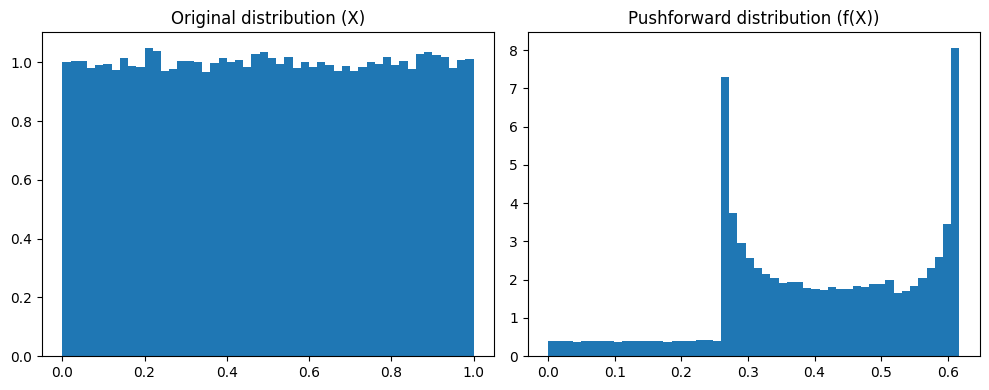

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. X ~ Uniform(0,1)
N = 100000
X = np.random.rand(N)

# 2. The integrand
def f(x):
    return x**2 + 0.5*np.sin(5*x)

Y = f(X)

# 3. The two expectations must be the same
E1 = np.mean(Y)  # E[f(X)]

# Calculate the pushforward measure using density histogram representation
hist_vals, bin_edges = np.histogram(Y, bins=200, density=True)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])
E2 = np.sum(bin_centers * hist_vals * np.diff(bin_edges))

print("E[f(X)] =", E1)
print("Integral w.r.t. pushforward =", E2)

# 4. Visualization
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(X, bins=50, density=True)
plt.title("Original distribution (X)")

plt.subplot(1,2,2)
plt.hist(Y, bins=50, density=True)
plt.title("Pushforward distribution (f(X))")

plt.tight_layout()
plt.show()

### $L^p$ Spaces, Hölder and Minkowski Inequalities

Let $(X,\mathcal{B}(X),\mu)$ be a measure space.

- For $1 \le p < \infty$, define
$$
L^p(\mu) := \left\{ f : X \to \mathbb{R} \text{ measurable } \;\middle|\; \int_X |f(x)|^p \,\mu(dx) < \infty \right\}.
$$

- Define
$$
L^\infty(\mu) := \left\{ f : X \to \mathbb{R} \text{ measurable } \;\middle|\; \|f\|_\infty < \infty \right\},
$$
where
$$
\|f\|_\infty := \inf \{ M \ge 0 \mid |f(x)| \le M \text{ for } \mu\text{-almost every } x \}.
$$

- The $L^p$ norm is
$$
\|f\|_p := \left( \int_X |f(x)|^p \,\mu(dx) \right)^{1/p}, \quad 1 \le p < \infty.
$$

- Functions equal $\mu$-almost everywhere are identified.

- $(L^p(\mu), \|\cdot\|_p)$ is a Banach space for all $1 \le p \le \infty$.

  
**Hölder's Inequality:** Let $1 \le p,q \le \infty$ with
$$
\frac{1}{p} + \frac{1}{q} = 1
$$
(with the conventions $1/\infty = 0$, $1/0 = \infty$).

If $f \in L^p(\mu)$ and $g \in L^q(\mu)$, then
$$
\int_X |f(x)g(x)|\,\mu(dx)
\;\le\;
\|f\|_p \, \|g\|_q.
$$

**Theorem (Minkowski Inequality):** Let $1 \le p \le \infty$. If $f,g \in L^p(\mu)$, then
$$
\|f + g\|_p \le \|f\|_p + \|g\|_p.
$$

**Remarks:**
- For $p=2$, $L^2(\mu)$ is a Hilbert space with inner product
$$
\langle f,g \rangle = \int_X f(x)g(x)\,\mu(dx).
$$

- Hölder's inequality implies duality between $L^p$ and $L^q$ for $1<p<\infty$, and between $L^1$ and $L^\infty$.
Minkowski
- Minkowski's inequality shows that $\|\cdot\|_p$ is a norm for all $1 \le p \le \infty$.

### Interchanging Limits and Integrals (Fatou, Beppo–Levi, Lebesgue)

Let $(X,\mathcal{B}(X),\mu)$ be a measure space and $(f_n)$ a sequence of measurable functions.

**Theorem (Fatou's Lemma):**
If $f_n \ge 0$ $\mu$-almost everywhere for all $n$, then
$$
\int_X \liminf_{n\to\infty} f_n(x)\,\mu(dx)
\;\le\;
\liminf_{n\to\infty} \int_X f_n(x)\,\mu(dx).
$$

**Theorem (Beppo–Levi Theorem or Monotone Convergence):**
If $0 \le f_n \uparrow f$ pointwise $\mu$-almost everywhere (i.e. $f_n$ is increasing and converges to $f$), then
$$
\int_X f_n(x)\,\mu(dx)
\;\uparrow\;
\int_X f(x)\,\mu(dx).
$$

**Theorem (Lebesgue's Dominated Convergence Theorem):**

Assume:
- $f_n \to f$ pointwise $\mu$-almost everywhere,
- there exists $g \in L^1(\mu)$ such that $|f_n(x)| \le g(x)$ $\mu$-almost everywhere for all $n$.

Then:
- $f \in L^1(\mu)$,
- and
$$
\lim_{n\to\infty} \int_X f_n(x)\,\mu(dx)
=
\int_X f(x)\,\mu(dx).
$$

**Remarks:**
- Fatou's lemma gives a lower bound without any convergence assumption.
- Beppo–Levi applies to nonnegative increasing sequences.
- Dominated convergence allows signed functions under an $L^1$ bound.

These results provide the main tools for justifying the interchange of limits and integrals.

## Densities

Let $(X,\mathcal{B}(X))$ be a measurable space and let $\mu,\nu$ be measures.

- We say that $\nu$ is **absolutely continuous** with respect to $\mu$, and write $\nu \ll \mu$, if
$$
\mu(A)=0 \;\Rightarrow\; \nu(A)=0.
$$

- A measure $\mu$ is said to **dominate** a family of measures $(\mu_i)_{i\in I}$ if $\mu_i \ll \mu$ for all $i \in I$.

**Example:**  
The Dirac measure $\delta_0$ is not absolutely continuous with respect to the Lebesgue measure $\lambda$, since
$$
\delta_0(\{0\}) = 1 \quad \text{while} \quad \lambda(\{0\}) = 0.
$$

**Theorem (Radon–Nikodym).**  
Let $\mu$ and $\nu$ be measures on $X$ such that $\mu \ll \nu$. Then there exists a measurable function $f : X \to [0,\infty)$ such that
$$
\mu(A) = \int_A f(x)\,\nu(dx), \qquad A \in \mathcal{B}(X).
$$
The function $f$ is called the density of $\mu$ with respect to $\nu$, or the Radon–Nikodym derivative, and is commonly denoted by
$$
f = \frac{d\mu}{d\nu}.
$$
Moreover, for $\nu$-almost every $x \in X$,
$$
\frac{d\mu}{d\nu}(x) = \lim_{r \downarrow 0} \frac{\mu\big(B_r(x)\big)}{\nu\big(B_r(x)\big)}.
$$

A $\mathbb{R}^d$-valued random variable $f$ is called absolutely continuous—or simply continuous—if its distribution is absolutely continuous with respect to the Lebesgue measure.

### Kernels, disintegration, conditional distributions and couplings


**Definition:** Let $X$ and $Y$ be measurable spaces. A mapping
$$
\kappa: X \times \mathcal{B}(Y) \to [0,1]
$$
is called a *probability kernel* if:

1. For every fixed $x \in X$, the set function $A \mapsto \kappa(x,A)$ is a Borel probability measure on $\mathcal{B}(Y)$.
2. For every fixed $A \in \mathcal{B}(Y)$, the function $x \mapsto \kappa(x,A)$ is measurable.

---

**Theorem (Disintegration of measures):**  
Let $X$ and $Y$ be complete separable metric spaces, let $h: Y \to X$ be a measurable map, and let $\mu \in \mathcal{P}(Y)$. Define $\nu := \mu \circ h^{-1}$. Then there exists a probability kernel
$$
\kappa: X \times \mathcal{B}(Y) \to [0,1]
$$
such that for every integrable function $g$,
$$
\int_Y g(y)\,\mu(dy)
=
\int_X \int_{h^{-1}(\{x\})} g(y)\,\kappa(x,dy)\,\nu(dx).
$$

The kernel $\kappa$ is called a **conditional distribution of $\mu$ given $h$ with respect to $\nu$**.

**Problem 1:** Let $\mu$ be the Lebesgue measure on the quarter of the unit disk
$$
A=\{(x,y)\in[0,1]^2 : x^2+y^2\le 1\},
$$
normalized to be a probability measure. Determine the marginals of $\mu$ and the result of its disintegration.


**Solution:** Let $\pi_i:\mathbb{R}^2\to\mathbb{R}$, $i=1,2$, denote the canonical projections.  
The density of $\mu$ is given by
$$
\rho(x,y)=\frac{4}{\pi}\mathbf{1}_A(x,y).
$$

The densities of the marginal measures $\mu\circ\pi_i^{-1}$, $i=1,2$, are
$$
\rho_i(x)
= \frac{4}{\pi}\mathbf{1}_{[0,1]}(x)\int_0^{\sqrt{1-x^2}} 1\,\mathrm{d}y
= \frac{4}{\pi}\sqrt{1-x^2}\,\mathbf{1}_{[0,1]}(x), 
\quad i=1,2.
$$

By symmetry, the marginals $\mu\circ\pi_1^{-1}$ and $\mu\circ\pi_2^{-1}$ coincide.

The disintegration is given by
$$
\mu_x(\mathrm{d}y)
=
\frac{\rho(x,y)}{\rho_1(x)}\,\mathrm{d}y
=
\frac{1}{\sqrt{1-x^2}}
\mathbf{1}_{[0,\sqrt{1-x^2}]}(y)\,\mathrm{d}y,
\quad x\in[0,1].
$$

---

## The space $\mathcal{P}(\mathbb{R}^d)$

Let $\mathcal{P}(\mathbb{R}^d)$
denote the set of all Borel probability measures on $\mathbb{R}^d$, i.e., all Borel measures $\mu$ such that $\mu(\mathbb{R}^d)=1$.

### Kantorovich–Rubinstein metric and weak convergence

**Kantorovich–Rubinstein metric:** Let $\mu,\nu \in \mathcal{P}(\mathbb{R}^d)$. The Kantorovich–Rubinstein metric is defined as
$$
d_{KR}(\mu,\nu)
:= \sup_{\|f\|\le 1,\,\|f\|_{\mathrm{Lip}}\le 1} \left| \int_{\mathbb{R}^d} f\,d(\mu-\nu)\right|,
$$
where the supremum is taken over all 1-Lipschitz functions $f:\mathbb{R}^d \to \mathbb{R}$.

**Weak convergence:** A sequence $\mu_n \in \mathcal{P}(\mathbb{R}^d)$ is said to converge **weakly** to $\mu$ if for every bounded continuous function $f \in C_b(\mathbb{R}^d)$,
$$
\lim_{n \to \infty} \int_{\mathbb{R}^d} f\, d\mu_n
=
\int_{\mathbb{R}^d} f\, d\mu.
$$

**Example (Central Limit Theorem):** Let $(X_i)_{i\geq 1}$ be a sequence of i.i.d. real-valued random variables with  
$\mathbb{E}[X_1]=0$ and $\mathrm{Var}(X_1)=\sigma^2 \in (0,\infty)$. Define the normalized sums
$$
S_n := \frac{1}{\sqrt{n}} \sum_{i=1}^n X_i.
$$
Let $\mu_n := \mathcal{L}(S_n)$ denote the law of $S_n$. Then
$$
\mu_n \Rightarrow \mathcal{N}(0,\sigma^2),
$$
i.e., the sequence $(\mu_n)$ converges weakly to the Gaussian measure with mean $0$ and variance $\sigma^2$.  

Equivalently, for every $f \in C_b(\mathbb{R})$,
$$
\lim_{n\to\infty} \mathbb{E}[f(S_n)]
=
\int_{\mathbb{R}} f(x)\,\frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{x^2}{2\sigma^2}}\,dx.
$$

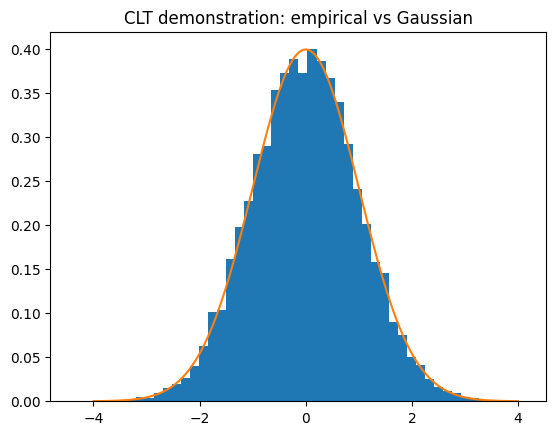

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# parameters
n = 50          # sample size
N = 10000       # number of repetitions
sigma = 1.0

# simulate CLT
X = np.random.normal(loc=0.0, scale=sigma, size=(N, n))
S_n = X.mean(axis=1) * np.sqrt(n)  # normalized sum

# plot histogram vs Gaussian density
x = np.linspace(-4, 4, 400)

plt.hist(S_n, bins=50, density=True)
plt.plot(x, norm.pdf(x, loc=0, scale=sigma))

plt.title("CLT demonstration: empirical vs Gaussian")
plt.show()

**Theorem.** The space $\mathcal{P}(\mathbb{R}^d)$, equipped with the Kantorovich–Rubinstein metric $d_{KR}$, is a complete and separable metric space. Moreover, a sequence $(\mu_n)_{n\in\mathbb{N}} \subset \mathcal{P}(\mathbb{R}^d)$ converges weakly to a measure $\mu \in \mathcal{P}(\mathbb{R}^d)$ if and only if
$$
d_{KR}(\mu_n,\mu) \to 0 \quad \text{as } n \to \infty.
$$

**Example (Dirac measures):** For $x,y \in \mathbb{R}^d$,
$$
d_{KR}(\delta_x,\delta_y)=\|x-y\|.
$$

Hence, the mapping $x \mapsto \delta_x$ defines an isometric embedding of $\mathbb{R}^d$ into the space $\mathcal{P}(\mathbb{R}^d)$ equipped with the Kantorovich–Rubinstein (Wasserstein-1) metric.

**Example ($\delta_0$ and the uniform distribution on $[0,1]$):**
Let $\lambda_{[0,1]}$ denote the uniform measure on $[0,1]$. Then
$$
d_{KR}(\delta_0,\lambda_{[0,1]})
= \int_0^1 |x|\,dx
= \frac{1}{2}.
$$


**Example (absolute continuous distributions are dense in $\mathcal{P}(\mathbb{R}^d)$):** Let $\psi \in C_0^\infty(\mathbb{R}^d)$ be a standard mollifier i.e. satisfies
$$
\psi \ge 0, \qquad \int \psi(x)\,dx = 1.
$$
Define $\psi_n(x) = n^d \psi(nx)$ and
$$
\mu * \psi_n (x) = \int \psi_n(x-y)\,\mu(dy).
$$
Then the sequence $\mu_n = (\mu * \psi_n)(x)\,dx$ converges weakly to $\mu$.

Indeed, for every $\varphi \in C_b(\mathbb{R}^d)$ we have
$$
\int \varphi(x)\, d\mu_n
=
\int \left(\int \varphi(y + n^{-1} z)\psi(z)\,dz\right)\mu(dy),
$$
where the right-hand side converges to $\int \varphi\, d\mu$ by the dominated convergence theorem.

#### Compactness in $\mathcal{P}(\mathbb{R}^d)$

**Theorem (Prokhorov):**

(i) Let $(\mu_n)$ be a sequence of probability measures. If $(\mu_n)$ converges weakly to a probability measure $\mu$, then for every $\varepsilon > 0$ there exists a compact set $K_\varepsilon$ such that
$$
\mu_n(K_\varepsilon) > 1 - \varepsilon \quad \text{for all } n.
$$

(ii) Conversely, if a sequence of probability measures $(\mu_n)$ satisfies that for every $\varepsilon > 0$ there exists a compact set $K_\varepsilon$ such that
$$
\mu_n(K_\varepsilon) > 1 - \varepsilon \quad \text{for all } n,
$$
then there exists a subsequence $(\mu_{n_j})$ that converges weakly to some probability measure.

**Problem:**  
Let $(\mu_n)$ be probability measures, $V \ge 0$ a function, and assume that for every $R>0$ the sublevel set
$$
\{x \in X : V(x) \le R\}
$$
is compact. Suppose there exists $C>0$ such that
$$
\int_X V \, d\mu_n \le C
$$
for all $n$. Prove that one can extract a weakly convergent subsequence from $(\mu_n)$.

**Solution.**  
Assume that $X$ is a complete separable metric space. By Prokhorov’s theorem, it suffices to show that the family $\{\mu_n\}$ is tight, i.e., for every $\varepsilon>0$ there exists a compact set $K_\varepsilon \subset X$ such that
$$
\mu_n(K_\varepsilon) \ge 1-\varepsilon \quad \text{for all } n.
$$

We choose the sublevel sets of $V$ as candidate compact sets:
$$
K_\varepsilon := \{x \in X : V(x) \le R\}.
$$

By Markov’s inequality, for any $R>0$,
$$
\mu_n(\{V > R\})
\le \frac{1}{R} \int_X V \, d\mu_n
\le \frac{C}{R}.
$$

Choosing $R \ge \frac{C}{\varepsilon}$, we obtain
$$
\mu_n(\{V > R\}) \le \varepsilon,
$$
hence
$$
\mu_n(K_\varepsilon) \ge 1-\varepsilon \quad \text{for all } n.
$$

Since $K_\varepsilon$ is compact by assumption, the family $\{\mu_n\}$ is tight. Therefore, by Prokhorov’s theorem, there exists a weakly convergent subsequence.

#### Approximation in $\mathcal{P}(\mathbb{R}^d)$

**Theorem:** Any probability measure $\mu \in \mathcal{P}(\mathbb{R}^d)$ can be approximated by discrete measures of the form
$$
\mu_n = c_1 \delta_{x_1} + \cdots + c_n \delta_{x_n},
$$
where $x_i \in \mathbb{R}^d$, $c_i \ge 0$, and $\sum_{i=1}^n c_i = 1$.

**Proof:**
First assume that $\mathrm{Sp}(\mu) \subset K$, where $K$ is a cube. Let $\varepsilon > 0$ and partition $K$ into finitely many subcubes of diameter less than $\varepsilon$:
$$
K = \bigcup_{i=1}^n K_i.
$$
Let $x_i$ be the center of $K_i$, and set $c_i = \mu(K_i)$ for $i=1,\dots,n$. Let $\phi : \mathbb{R}^d \to [-1,1]$ be a test function satisfying
$$
|\phi(x) - \phi(y)| \le \|x - y\|, \quad x,y \in \mathbb{R}^d.
$$

Then
$$
\int_{\mathbb{R}^d} \phi(x)\,(\mu - \mu_n)(dx)
= \sum_{i=1}^n \int_{K_i} \phi(x)\,\mu(dx) - \phi(x_i)\mu(K_i),
$$
which can be rewritten and estimated as
$$
\sum_{i=1}^n \int_{K_i} \bigl(\phi(x) - \phi(x_i)\bigr)\,\mu(dx)
\le \sum_{i=1}^n \int_{K_i} \|x - x_i\|\,\mu(dx)
$$
$$
\le \varepsilon \sum_{i=1}^n \int_{K_i} 1 \,\mu(dx)
= \varepsilon.
$$

Since $\phi$ was arbitrary in the unit ball of Lipschitz functions, it follows that
$$
d_{KR}(\mu_n, \mu) < \varepsilon.
$$

If $\mathrm{Sp}(\mu)$ is not contained in a cube, define for $R>0$ the truncated and renormalized measure
$$
\mu^R(A) = \frac{1}{\mu([-R,R]^d)} \mu\bigl(A \cap [-R,R]^d\bigr).
$$
Let $\phi \in C_b(\mathbb{R}^d)$ be bounded and continuous. By the dominated convergence theorem,
$$
\int_{\mathbb{R}^d} \phi(x)\,\mu^R(dx)
= \frac{1}{\mu([-R,R]^d)} \int_{\mathbb{R}^d} \phi(x)\mathbf{1}_{[-R,R]^d}(x)\,\mu(dx)
\to \int_{\mathbb{R}^d} \phi(x)\,\mu(dx), \quad R \to \infty.
$$

Thus $\mu^R \Rightarrow \mu$ weakly as $R \to \infty$. Since each $\mu^R$ can be approximated by discrete measures, the same holds for $\mu$.

**Corollary:** Any probability measure $\mu \in \mathcal{P}(\mathbb{R}^d)$ can be approximated by finite mixtures of Gaussian distributions, i.e.,
$$
\mu_n = \sum_{i=1}^n c_i \,\mathcal{N}(m_i,\Sigma_i),
$$
where $c_i \ge 0$, $\sum_{i=1}^n c_i = 1$, $m_i \in \mathbb{R}^d$, and $\Sigma_i$ are positive definite covariance matrices.

## Wasserstein distance

<div style="display: flex;">
  <div style="flex: 50%; padding: 10px;">
    <p>
        
The theory of optimal transport can be motivated by a simple transport problem: 

- Imagine a set of bakeries producing bread and a set of shops demanding it.
  
- Each bakery distributes its production according to a probability measure, and each shop represents a target distribution of demand.
  
- The question is: how should we optimally transport the mass (bread) from the bakeries to the shops in order to minimize the total transportation cost?
        
  </p>
  </div>
  <div style="flex: 50%; padding: 10px;">
    <p><div style="text-align: center;">
<img src="./pekseg.png" width="450" height="300">
</div></p>
  </div>
</div>

>To formalize this idea, we introduce the concept of a **coupling**.

<div style="display: flex;">
  <div style="flex: 50%; padding: 10px;">
    <p>
        
**Definition (Coupling):** Let $\mu, \nu \in \mathcal{P}(\mathbb{R}^d)$. A coupling of $\mu$ and $\nu$ is a probability measure $\pi$ on $\mathbb{R}^d \times \mathbb{R}^d$ such that for all Borel sets $A, B \subset \mathbb{R}^d$,
$$
\pi(A \times \mathbb{R}^d) = \mu(A), \quad \pi(\mathbb{R}^d \times B) = \nu(B).
$$

The set of all such couplings is denoted by $\Pi(\mu,\nu)$.

**Definition (Wasserstein distance):** Let $p \ge 1$ and $\mu, \nu \in \mathcal{P}_p(\mathbb{R}^d)$, i.e. probability measures with finite $p$-th moment. The Wasserstein distance of order $p$ is defined by
$$
W_p(\mu,\nu)
=
\left(
\inf_{\pi \in \Pi(\mu,\nu)}
\int_{\mathbb{R}^d \times \mathbb{R}^d} \|x-y\|^p \, d\pi(x,y)
\right)^{1/p}.
$$

  </p>
  </div>
  <div style="flex: 50%; padding: 10px;">
    <p><div style="text-align: center;">
<img src="./transport_plan.png" width="350" height="350">
</div></p>
  </div>
</div>



**Theorem:** The space $\mathcal{P}_p(\mathbb{R}^d)$ equipped with the Wasserstein distance $W_p$ is a complete and separable metric space.

Moreover, for a sequence $(\mu_n) \subset \mathcal{P}_p(\mathbb{R}^d)$ and $\mu \in \mathcal{P}_p(\mathbb{R}^d)$, the following are equivalent:
- $\mu_n \to \mu$ in $W_p$, i.e. $W_p(\mu_n,\mu) \to 0$,
- $\mu_n \Rightarrow \mu$ weakly, and
$$
\int_{\mathbb{R}^d} \|x\|^p \, d\mu_n(x) \to \int_{\mathbb{R}^d} \|x\|^p \, d\mu(x).
$$

#### Neural approximation of distributions and generative models

A central paradigm in modern generative modeling is to represent a target distribution $\mu \in \mathcal{P}(\mathbb{R}^d)$ as the pushforward of a simple base distribution. Let $Z \sim \mathcal{N}(0,I)$ and let $f_\theta : \mathbb{R}^k \to \mathbb{R}^d$ be a neural network. The induced distribution
$$
\mu_\theta := \mathcal{N}(0,I)\circ f_\theta^{-1}
$$
is called a **generative model**.

Under mild conditions, neural networks are rich enough to approximate transport maps, and hence the family $\{\mu_\theta\}_\theta$ is dense in $\mathcal{P}(\mathbb{R}^d)$ with respect to weak convergence or Wasserstein distances. In this sense, neural networks provide a flexible, nonparametric way to approximate arbitrary probability measures.

This viewpoint unifies several major classes of generative models:
- **GANs:** learn $f_\theta$ by minimizing an integral probability metric, often related to the Wasserstein distance.
- **Normalizing flows:** restrict $f_\theta$ to be invertible, allowing explicit density evaluation via the change-of-variables formula.
- **Diffusion / score-based models:** construct $\mu$ via a stochastic flow that can be interpreted as an infinite-dimensional transport.

Thus, generative models can be seen as learning a transport map from a simple reference distribution to the target distribution, generalizing classical approximation schemes such as discrete or Gaussian mixture approximations.

## Total variation distance on $\mathcal{P}(\mathbb{R}^d)$

The total variation distance is a fundamental notion for comparing probability measures. It captures the maximal discrepancy between two distributions over all possible events.

A useful intuition comes from coupling: imagine two different probabilistic “machines” producing outcomes, and we try to synchronize them as much as possible so that their outputs agree with high probability.

**Definition (Total variation distance):**  
$$
d_{\mathrm{TV}}(\mu,\nu)
=
\inf_{\pi \in \Pi(\mu,\nu)} \int_{\mathbb{R}^d \times \mathbb{R}^d} \mathbf{1}_{x\ne y} \, d\pi(x,y)
$$

This shows that total variation distance measures how well one can couple two distributions so that they agree with maximal probability.

**Properties:**
- Total variation distance is extremely strong: $d_{\mathrm{TV}}(\mu_n,\mu) \to 0$ implies convergence of expectations of all bounded measurable functions. In particular, it dominates weak convergence.

- It is widely used in probability theory, Markov chain mixing, and statistical hypothesis testing, where it quantifies the optimal success probability of distinguishing two distributions.

## Wasserstein Style Transfer
  
Given a content image $I_c$ and a style image $I_s$, extract feature maps with a fixed network (e.g. a convolutional encoder). This yields two empirical distributions of feature vectors:
$$
\mu_c = \frac{1}{n}\sum_{i=1}^n \delta_{f_c^i}, 
\qquad
\mu_s = \frac{1}{m}\sum_{j=1}^m \delta_{f_s^j},
$$
where $f_c^i, f_s^j \in \mathbb{R}^k$ are feature vectors at spatial locations.

The goal is to **transport** $\mu_c$ onto $\mu_s$. This is done by solving an optimal transport problem with quadratic cost:
$$
\min_{\pi \in \Pi(\mu_c,\mu_s)} \sum_{i,j} \|f_c^i - f_s^j\|^2 \,\pi_{ij}.
$$

From the optimal plan $\pi$, define transported features:
$$
\tilde f_c^i = \frac{1}{\sum_j \pi_{ij}} \sum_{j} \pi_{ij}\, f_s^j.
$$

These $\tilde f_c^i$ have (approximately) the **same distribution as the style features**, while preserving spatial alignment from the content.

Finally, reconstruct an image $\tilde I$ whose features match $\tilde f_c$ (e.g. by optimization or a decoder network).

<div style="text-align: center;">
<img src="./styletransfer2.png" width="600" height="400">
</div>

**Intuition.**  
- Content = spatial structure (positions of features)  
- Style = distribution of features  
- Optimal transport = minimal-cost way to “reshape” one distribution into the other  

Thus style transfer becomes:
$$
\text{match feature distributions in Wasserstein sense while keeping geometry.}
$$


<div style="display: flex;">
  <div style="flex: 50%; padding: 10px;">
    <p>
        
**Further readings**

- Korotin, A., Selikhanovych, D., & Burnaev, E.  
  *Neural Optimal Transport*.  
  arXiv:2201.12220 (2022). 

- Mroueh, Y.  
  *Wasserstein Style Transfer*.  
  arXiv:1905.12828 (2019).

- Kolkin, N., Salavon, J., & Shakhnarovich, G.  
  *Style Transfer by Relaxed Optimal Transport and Self-Similarity*.  
  arXiv:1904.12785 (2019).

        
  </p>
  </div>
  <div style="flex: 50%; padding: 10px;">
    <p><div style="text-align: center;">
<img src="./burnaev.png" width="600" height="300">
</div></p>
  </div>
</div>